# SMBHB Population Analysis Across Runs and Scenarios

This notebook finds and analyses saved `consistent_pop_synth` outputs across multiple runs.

It compares scenarios (optimistic/realistic/pessimistic) using:
- nearest binary distance per simulation
- loudest proxy per simulation (`max h0`)
- distributions of chirp mass, frequency, and distance

The loader is built to handle both of these formats:
1. population saved as a list of per-binary dictionaries
2. population saved as a stringified `PopulationArrays(...)` representation

In [2]:
from __future__ import annotations

import json
import gzip
import pickle
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_columns', 50)

SCENARIOS = ('optimistic', 'realistic', 'pessimistic')

In [3]:
def infer_scenario(path: Path) -> str:
    lower_parts = [p.lower() for p in path.parts]
    for s in SCENARIOS:
        if s in lower_parts or s in path.name.lower():
            return s
    return 'unknown'


def infer_run_id(path: Path) -> str:
    date_re = re.compile(r'^\d{4}-\d{2}-\d{2}$')
    for p in path.parts:
        if date_re.match(p):
            return p
    return 'legacy'


def discover_result_files(data_root: Path = Path('data')) -> list[Path]:
    # Preferred order: compressed pickle -> pickle -> json fallback.
    pkl_gz_files = set(data_root.rglob('consistent_population_*.pkl.gz'))
    pkl_files = set(data_root.rglob('consistent_population_*.pkl'))
    pkl_files.update(data_root.rglob('consistent_pop_synth.pkl'))

    json_files = set(data_root.rglob('consistent_pop_synth.json'))
    json_files.update(data_root.glob('consistent_pop_synth_*.json'))
    json_files.update(data_root.rglob('consistent_population_*.json'))

    files = sorted(pkl_gz_files) + sorted(pkl_files) + sorted(json_files)
    return [p for p in files if p.is_file()]


result_files = discover_result_files(Path('data'))
print(f'Discovered {len(result_files)} result files (pkl.gz preferred)')
for p in result_files[::-1][:20]:  # Show most recent 20 files
    print('-', p)
if len(result_files) > 20:
    print('...')

Discovered 69 result files (pkl.gz preferred)
- data/consistent_pop_synth_optimistic.json
- data/2026-04-28/optimistic/consistent_population_optimistic_targetSNR4.25_sims1.json
- data/2026-04-27/optimistic/consistent_population_optimistic_targetSNR4.25_sims1.json
- data/2026-04-24/optimistic/consistent_population_optimistic_targetSNR4.25_sims1.json
- data/2026-04-23/optimistic/consistent_population_optimistic_targetSNR4.25_sims1.json
- data/2026-04-22/optimistic/consistent_population_optimistic_targetSNR4.25_sims1.json
- data/2026-04-21/realistic/consistent_population_realistic_targetSNR4.25_sims1.json
- data/2026-04-21/optimistic/consistent_population_optimistic_targetSNR4.25_sims1.json
- data/2026-04-20/realistic/consistent_population_realistic_targetSNR4.25_sims1.json
- data/2026-04-17/realistic/consistent_population_realistic_targetSNR4.25_sims1.json
- data/2026-04-16/realistic/consistent_population_realistic_targetSNR4.25_sims1.json
- data/2026-04-16/optimistic/consistent_populati

In [4]:
def _extract_array_from_population_string(pop_text: str, key: str) -> np.ndarray | None:
    # Extract key=array([ ... ]) from stringified PopulationArrays(...) output.
    pattern = rf"{re.escape(key)}=array\(\[(.*?)\]"
    match = re.search(pattern, pop_text, flags=re.DOTALL)
    if not match:
        return None

    raw = match.group(1).replace('\n', ' ')

    # Fast path for clean comma-separated numeric strings.
    try:
        arr = np.fromstring(raw, sep=',')
    except ValueError:
        arr = np.array([], dtype=float)

    if arr.size == 0 and raw.strip():
        # Fallback for whitespace-only separation / mixed separators.
        try:
            arr = np.fromstring(raw.replace(',', ' '), sep=' ')
        except ValueError:
            arr = np.array([], dtype=float)

    if arr.size == 0 and raw.strip():
        # Robust fallback: extract numeric tokens even if extra text is present.
        tokens = re.findall(
            r'[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?|[-+]?inf|nan',
            raw,
            flags=re.IGNORECASE,
        )
        if tokens:
            arr = np.asarray([float(t) for t in tokens], dtype=float)

    return arr if arr.size > 0 else None


def _population_to_arrays(population_obj) -> dict[str, np.ndarray] | None:
    # Case 1: population stored as dict with list/array values (compact representative format)
    if isinstance(population_obj, dict):
        # Check if it looks like the compact format (has f, Mc, etc. as keys)
        has_pop_fields = any(k in population_obj for k in ('f', 'Mc', 'Mtot', 'D_comov', 'h0', 'z'))
        if has_pop_fields:
            out = {}
            for k in ('f', 'Mc', 'D', 'D_comov', 'h0', 'z', 'Mtot'):
                if k in population_obj:
                    arr = population_obj[k]
                    if arr is not None:
                        out[k] = np.asarray(arr, dtype=float)
            return out if out else None

    # Case 2: population stored as list of dict rows (legacy format)
    if isinstance(population_obj, list):
        if not population_obj:
            return None
        out = {}
        for k in ('f', 'Mc', 'D', 'D_comov', 'h0', 'z'):
            vals = [row.get(k, np.nan) for row in population_obj]
            out[k] = np.asarray(vals, dtype=float)
        return out

    # Case 3: true PopulationArrays object (via pickle)
    if hasattr(population_obj, 'f') and hasattr(population_obj, 'Mc'):
        out = {}
        for k in ('f', 'Mc', 'D', 'D_comov', 'h0', 'z'):
            if hasattr(population_obj, k):
                arr = getattr(population_obj, k)
                if arr is not None:
                    out[k] = np.asarray(arr, dtype=float)
        return out if out else None

    # Case 4: stringified PopulationArrays(...) (legacy JSON fallback)
    if isinstance(population_obj, str):
        out = {}
        for k in ('f', 'Mc', 'D', 'D_comov', 'h0', 'z'):
            arr = _extract_array_from_population_string(population_obj, k)
            if arr is not None:
                out[k] = arr.astype(float)
        return out if out else None

    return None

def _entry_to_binary_rows(entry: dict, source_file: Path, scenario: str, run_id: str, fallback_sim_indexx: int) -> list[dict]:
    arrays = _population_to_arrays(entry.get('population'))
    if arrays is None:
        return []

    d = arrays.get('D_comov')
    if d is None:
        d = arrays.get('D')

    keys_for_len = [k for k in ('f', 'Mc', 'h0') if arrays.get(k) is not None]
    if d is not None:
        keys_for_len.append('D')

    if not keys_for_len:
        return []

    lengths = []
    for k in keys_for_len:
        if k == 'D':
            lengths.append(len(d))
        else:
            lengths.append(len(arrays[k]))

    n = int(min(lengths))
    if n == 0:
        return []

    sim_indexx = entry.get('sim_index', fallback_sim_indexx)
    sim_index = f"{run_id}:{sim_indexx}"

    rows = []
    for i in range(n):
        rows.append({
            'scenario': scenario,
            'run_id': run_id,
            'source_file': str(source_file),
            'sim_index': int(sim_indexx),
            'sim_index': sim_index,
            'binary_index': i,
            'f': float(arrays['f'][i]) if arrays.get('f') is not None else np.nan,
            'Mc': float(arrays['Mc'][i]) if arrays.get('Mc') is not None else np.nan,
            'D': float(d[i]) if d is not None else np.nan,
            'h0': float(arrays['h0'][i]) if arrays.get('h0') is not None else np.nan,
            'z': float(arrays['z'][i]) if arrays.get('z') is not None else np.nan,
        })
    return rows



def _load_payload(path: Path):
    suffixes = ''.join(path.suffixes).lower()
    if suffixes.endswith('.pkl.gz'):
        with gzip.open(path, 'rb') as f:
            return pickle.load(f)
    if path.suffix.lower() == '.pkl':
        with path.open('rb') as f:
            return pickle.load(f)
    with path.open('r') as f:
        return json.load(f)

In [5]:
def load_population_binary_table(files, verbose=False):
    chunks = []
    for fp in files:
        scenario = infer_scenario(fp)
        run_id = infer_run_id(fp)
        try:
            payload = _load_payload(fp)
        except Exception as e:
            if verbose: print(f"Failed {fp}: {e}")
            continue
        if not isinstance(payload, dict):
            continue
        pops = payload.get('populations', [])
        if not isinstance(pops, list) or not pops:
            continue
        for i, entry in enumerate(pops):
            if not isinstance(entry, dict):
                continue
            arrays = _population_to_arrays(entry.get('population'))
            if arrays is None:
                continue
            d = arrays.get('D_comov') if arrays.get('D_comov') is not None else arrays.get('D')
            f  = arrays.get('f')
            Mc = arrays.get('Mc')
            h0 = arrays.get('h0')
            z  = arrays.get('z')
            if f is None:
                continue
            n = len(f)
            sim_indexx = entry.get('sim_index', i)
            df_chunk = pd.DataFrame({
                'scenario':     scenario,
                'run_id':       run_id,
                'source_file':  str(fp),
                'sim_index':    np.int32(sim_indexx),
                'binary_index': np.arange(n, dtype=np.int32),
                'f':  f.astype(np.float32),
                'Mc': Mc.astype(np.float32) if Mc is not None else np.full(n, np.nan, np.float32),
                'D':  d.astype(np.float32)  if d  is not None else np.full(n, np.nan, np.float32),
                'h0': h0.astype(np.float32) if h0 is not None else np.full(n, np.nan, np.float32),
                'z':  z.astype(np.float32)  if z  is not None else np.full(n, np.nan, np.float32),
            })
            chunks.append(df_chunk)
    if not chunks:
        return pd.DataFrame()
    return pd.concat(chunks, ignore_index=True)


binary_df = load_population_binary_table(result_files, verbose=True)
print('Binary rows:', len(binary_df))
print('Loaded from file types:', sorted({''.join(Path(p).suffixes) for p in binary_df['source_file'].unique()}) if len(binary_df) else [])
binary_df.head()


/var/folders/_r/193g9tqs58s14y2d6dct04380000gn/T/ipykernel_4737/1020201996.py:38: RuntimeWarning: overflow encountered in cast
  'Mc': Mc.astype(np.float32) if Mc is not None else np.full(n, np.nan, np.float32),


Binary rows: 563015
Loaded from file types: ['.0_sims1.json', '.0_sims1.pkl.gz', '.0_sims10.json', '.0_sims3.json', '.0_sims3.pkl.gz', '.0_sims5.json', '.0_sims5.pkl', '.0_sims5.pkl.gz', '.25_sims1.json', '.25_sims1.pkl.gz', '.json']


,scenario,run_id,source_file,sim_index,binary_index,f,Mc,D,h0,z
0,pessimistic,2026-03-31,data/2026-03-31/pessimistic/consistent_populat...,0,0,1.988109e-09,59425776.00,14.657273,5.805032e-17,0.001866
1,pessimistic,2026-03-31,data/2026-03-31/pessimistic/consistent_populat...,0,1,2.846029e-09,3063566.25,53.388557,1.450285e-19,0.006805
2,pessimistic,2026-03-31,data/2026-03-31/pessimistic/consistent_populat...,0,2,2.135837e-09,76585168.00,59.063629,2.314930e-17,0.007529
3,pessimistic,2026-03-31,data/2026-03-31/pessimistic/consistent_populat...,0,3,2.045473e-09,29267762.00,60.878929,4.392207e-18,0.007761
4,pessimistic,2026-03-31,data/2026-03-31/pessimistic/consistent_populat...,0,4,2.520291e-09,12362148.00,63.616993,1.148918e-18,0.008111


In [ ]:
if binary_df.empty:
    raise RuntimeError('No binary rows loaded. Check available files and schema assumptions.')

sim_df = (
    binary_df.groupby(['scenario', 'run_id', 'source_file', 'sim_index'], as_index=False)
    .agg(
        n_binaries=('binary_index', 'count'),
        nearest_D=('D', 'min'),
        loudest_h0=('h0', 'max'),
        median_Mc=('Mc', 'median'),
        median_f=('f', 'median'),
    )
)

print('Simulations loaded:', len(sim_df))
display(sim_df.groupby('scenario', as_index=False).agg(sims=('sim_index', 'nunique'), binaries=('n_binaries', 'sum')))
display(sim_df.head())

: 

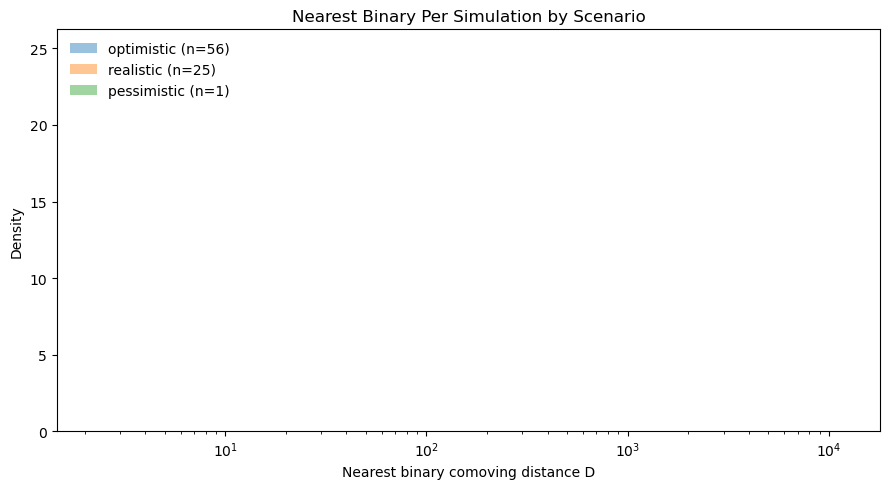

: 

In [ ]:
def hist_by_scenario(data_by_scenario: dict[str, np.ndarray], bins, xlabel: str, title: str, save = False, savename = None, logx: bool = False):
    fig, ax = plt.subplots(figsize=(9, 5))
    for scenario in SCENARIOS:
        vals = data_by_scenario.get(scenario)
        if vals is None or len(vals) == 0:
            continue
        ax.hist(vals, bins=bins, alpha=0.45, density=False, label=f"{scenario} (N_sims={len(vals)})")

    if logx:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()
    if save:
        plt.savefig(savename)
    return fig, ax


nearest_by_scenario = {
    s: sim_df.loc[sim_df['scenario'] == s, 'nearest_D'].dropna().to_numpy()
    for s in SCENARIOS
}

hist_by_scenario(
    nearest_by_scenario,
    bins=list(np.logspace(0, 4, 50)),
    xlabel='Nearest binary comoving distance D',
    title='Nearest Binary Per Simulation by Scenario',
    logx=True,
    save = True,
    savename="data/2026-04-01/nearest_SMBHB.png"
)


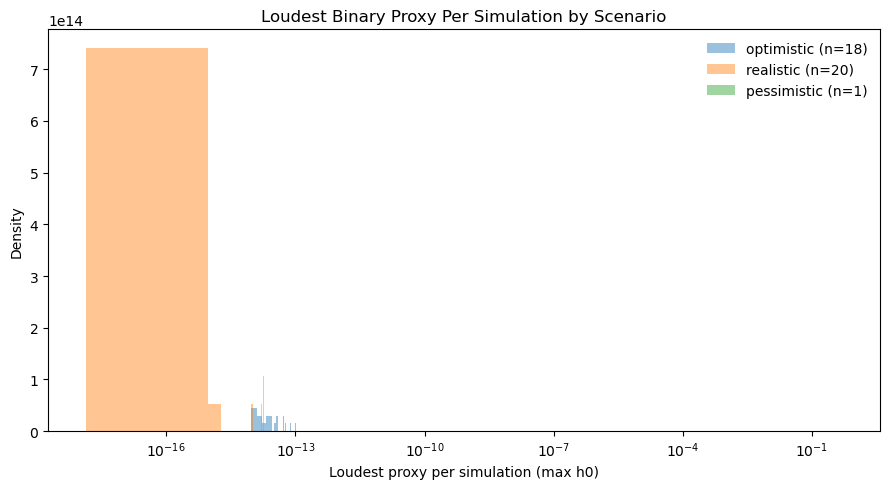

: 

In [ ]:
loudest_by_scenario = {
    s: sim_df.loc[sim_df['scenario'] == s, 'loudest_h0'].dropna().to_numpy()
    for s in SCENARIOS
}

_ = hist_by_scenario(
    loudest_by_scenario,
    bins=list(np.logspace(-15, -12, 50)),
    xlabel='Maximum h0 per simulation',
    title='Loudest Binary Proxy Per Simulation by Scenario',
    logx=True,
    save = True,
    savename="data/2026-04-01/biggest_h0_SMBHB.png"
)

FileNotFoundError: [Errno 2] No such file or directory: 'data/2026-04-01/distributions.png'

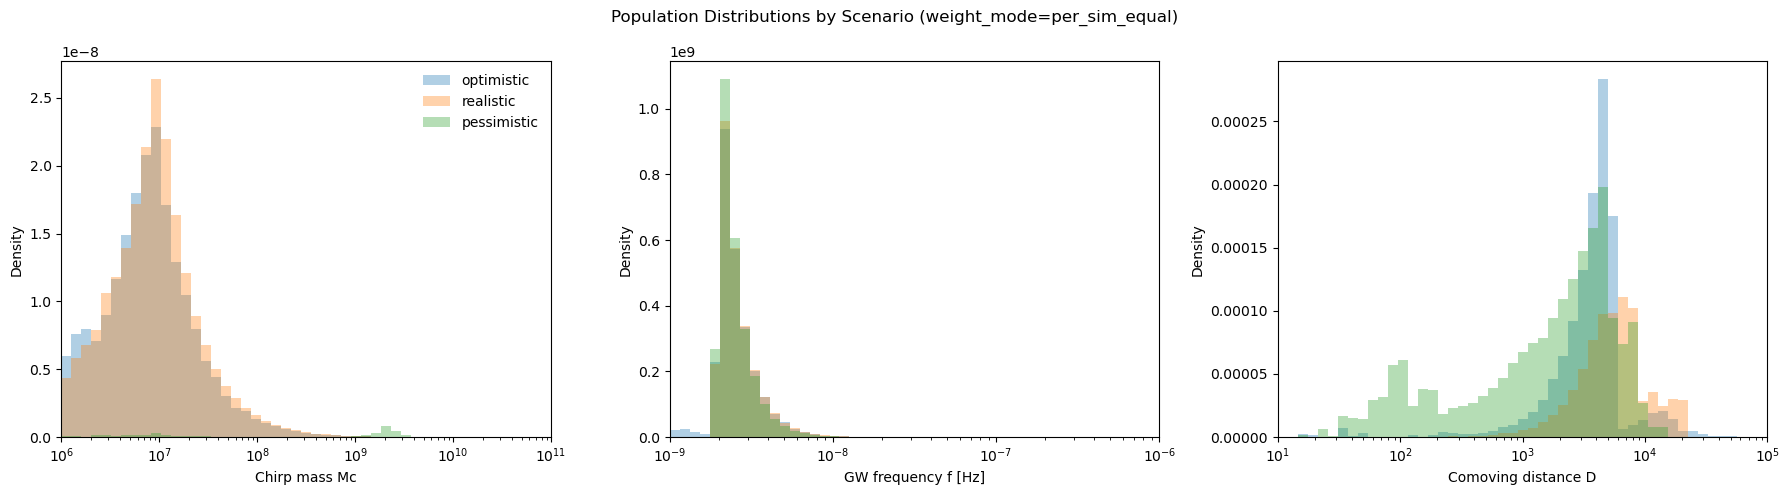

In [6]:
def add_distribution_weights(df: pd.DataFrame, mode: str = 'all_binaries') -> pd.DataFrame:
    out = df.copy()
    if mode == 'all_binaries':
        out['weight'] = 1.0
        return out

    if mode == 'per_sim_equal':
        counts = out.groupby('sim_index')['binary_index'].transform('count').astype(float)
        out['weight'] = 1.0 / counts
        return out

    raise ValueError("mode must be 'all_binaries' or 'per_sim_equal'")


weight_mode = 'per_sim_equal'  # change to 'per_sim_equal' if desired
dist_df = add_distribution_weights(binary_df, mode=weight_mode)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_specs = [
    ('Mc', 'Chirp mass Mc', True),
    ('f', 'GW frequency f [Hz]', True),
    ('D', 'Comoving distance D', True),
]
bins_mass = list(np.logspace(6, 11, 50))
bins_f = list(np.logspace(-9, -6, 50))
bins_dist = list(np.logspace(1, 5, 50))
bins = [bins_mass, bins_f, bins_dist]


for ax, (col, xlabel, logx), _bin in zip(axes, plot_specs, bins):
    for scenario in SCENARIOS:
        sub = dist_df[(dist_df['scenario'] == scenario) & np.isfinite(dist_df[col])]
        if sub.empty:
            continue
        ax.hist(
            sub[col].to_numpy(),
            bins=_bin,
            weights=sub['weight'].to_numpy(),
            density=True,
            alpha=0.35,
            label=scenario,
        )
    if logx:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_xlim(min(_bin), max(_bin))

axes[0].legend(frameon=False)
fig.suptitle(f'Population Distributions by Scenario (weight_mode={weight_mode})')
plt.tight_layout()
plt.savefig("data/2026-04-01/distributions.png")

In [ ]:
summary = (
    sim_df.groupby('scenario', as_index=False)
    .agg(
        n_sims=('sim_id', 'nunique'),
        nearest_D_median=('nearest_D', 'median'),
        nearest_D_p10=('nearest_D', lambda x: np.nanpercentile(x, 10)),
        nearest_D_p90=('nearest_D', lambda x: np.nanpercentile(x, 90)),
        loudest_h0_median=('loudest_h0', 'median'),
        loudest_h0_p10=('loudest_h0', lambda x: np.nanpercentile(x, 10)),
        loudest_h0_p90=('loudest_h0', lambda x: np.nanpercentile(x, 90)),
    )
)

summary

/opt/homebrew/anaconda3/envs/enter312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


,scenario,n_sims,nearest_D_median,nearest_D_p10,nearest_D_p90,loudest_h0_median,loudest_h0_p10,loudest_h0_p90
0,optimistic,49,478.684707,97.904536,1088.029194,3.788945e-14,1.748094e-14,8.525337e-14
1,realistic,5,295.352452,155.184964,693.610913,NaN,NaN,NaN


: 

## Notes on Combining Across Simulations

Default in this notebook:
- nearest/loudest metrics are per simulation (one point per sim), which is robust for scenario comparison
- distribution plots use all binaries by default (`weight_mode='all_binaries'`)

Alternative:
- set `weight_mode='per_sim_equal'` to avoid simulations with more binaries dominating parameter distributions

If you later add SNR contribution diagnostics, keep the same grouping key (`sim_id`) so all summaries stay aligned.

## Storage Recommendation

For your workflow, use one primary format by default: **compressed pickle (`.pkl.gz`)**.

Why this is the best default here:
- full-fidelity recovery of `PopulationArrays` objects
- much smaller than plain `.pkl`
- still straightforward to load in Python

When to additionally save `.npz`:
- only if disk size or data transfer is a bottleneck
- only for plotting/array workflows (not full object reconstruction)

In [ ]:
# Minimal examples
from pathlib import Path

from utils import load_results_pickle_gz, save_results_compact_npz

# 1) Preferred: load full-fidelity compressed pickle
pkl_gz_path = Path('data/2026-03-31/realistic/consistent_population_realistic_targetSNR4.0_sims10.pkl.gz')
if pkl_gz_path.exists():
    results_obj = load_results_pickle_gz(pkl_gz_path)
    print('Loaded:', pkl_gz_path)
    print('n sims:', len(results_obj.get('populations', [])))
else:
    print('Example file not found:', pkl_gz_path)

# 2) Optional: create compact NPZ for plotting-only pipelines
if 'results_obj' in locals():
    npz_path = pkl_gz_path.with_suffix('').with_suffix('.npz')
    save_results_compact_npz(results_obj, npz_path)
    print('Saved compact npz:', npz_path)

## Continuous GW (CGW) SNR Diagnostics

This section reads CGW diagnostics saved in the same `compact_results` structure used in `main.py`, i.e. per simulation:
- `compact_results['populations'][i]['population']`
- `compact_results['populations'][i]['cgw_analysis']['top_sources']`

It builds per-simulation metrics across scenarios and then plots:
- nearest SMBHB distance per simulation,
- loudest-by-CGW binary (`max SNR`) per simulation: `h0`, `Mc`, `D`, and `f`,
- two sky maps for loudest-by-CGW binaries: plain dots and SNR-colored.


In [7]:
# Build per-simulation CGW summaries from compact_results payloads across files.

from pathlib import Path
import numpy as np
import pandas as pd


def _extract_nearest_distance_from_population(population_obj) -> float:
    arrays = _population_to_arrays(population_obj)
    if arrays is None:
        return np.nan
    d = arrays.get('D_comov')
    if d is None:
        d = arrays.get('D')
    if d is None or len(d) == 0:
        return np.nan
    d = np.asarray(d, dtype=float)
    d = d[np.isfinite(d)]
    return float(np.min(d)) if d.size else np.nan


def _extract_loudest_cgw_source(entry: dict) -> dict | None:
    cgw = entry.get('cgw_analysis')
    if not isinstance(cgw, dict):
        return None
    top_sources = cgw.get('top_sources', [])
    if not isinstance(top_sources, list) or not top_sources:
        return None

    valid = [src for src in top_sources if isinstance(src, dict) and np.isfinite(src.get('snr', np.nan))]
    if not valid:
        return None
    return max(valid, key=lambda src: float(src.get('snr', -np.inf)))


def build_cgw_simulation_table(files) -> pd.DataFrame:
    records = []
    for fp in files:
        scenario = infer_scenario(fp)
        run_id = infer_run_id(fp)
        try:
            payload = _load_payload(fp)
        except Exception as e:
            print(f'Failed to load {fp}: {e}')
            continue

        if not isinstance(payload, dict):
            continue
        pops = payload.get('populations', [])
        if not isinstance(pops, list) or not pops:
            continue

        for i, entry in enumerate(pops):
            if not isinstance(entry, dict):
                continue

            nearest_d = _extract_nearest_distance_from_population(entry.get('population'))
            loudest = _extract_loudest_cgw_source(entry)
            if loudest is None:
                continue

            sim_indexx = int(entry.get('sim_index', i))
            records.append({
                'scenario': scenario,
                'run_id': run_id,
                'source_file': str(fp),
                'sim_index': sim_indexx,
                'sim_key': f"{scenario}:{run_id}:{sim_indexx}",
                'nearest_D': nearest_d,
                'loudest_cgw_snr': float(loudest.get('snr', np.nan)),
                'loudest_h0': float(loudest.get('h0', np.nan)),
                'loudest_Mc': float(loudest.get('Mc', np.nan)),
                'loudest_D': float(loudest.get('D_comov', loudest.get('D', np.nan))),
                'loudest_f': float(loudest.get('f', np.nan)),
                'loudest_ra': float(loudest.get('ra', np.nan)),
                'loudest_dec': float(loudest.get('dec', np.nan)),
            })

    if not records:
        return pd.DataFrame()
    return pd.DataFrame.from_records(records)


cgw_sim_df = build_cgw_simulation_table(result_files)
print('CGW simulations with top-source diagnostics:', len(cgw_sim_df))
if cgw_sim_df.empty:
    print('No per-simulation CGW diagnostics found. Ensure main.py saved compact_results with cgw_analysis.')
else:
    display(
        cgw_sim_df.groupby('scenario', as_index=False)
        .agg(
            n_sims=('sim_key', 'nunique'),
            median_top_snr=('loudest_cgw_snr', 'median'),
            median_nearest_D=('nearest_D', 'median'),
        )
    )
    display(cgw_sim_df.head())

CGW simulations with top-source diagnostics: 4


,scenario,n_sims,median_top_snr,median_nearest_D
0,optimistic,2,11.59127,1605.803223


,scenario,run_id,source_file,sim_index,sim_key,nearest_D,loudest_cgw_snr,loudest_h0,loudest_Mc,loudest_D,loudest_f,loudest_ra,loudest_dec
0,optimistic,2026-04-27,data/2026-04-27/optimistic/consistent_populati...,0,optimistic:2026-04-27:0,1268.281372,14.895129,1.678183e-14,7.795945e+10,17127.016241,3.249887e-09,4.003975,-0.183606
1,optimistic,2026-04-28,data/2026-04-28/optimistic/consistent_populati...,0,optimistic:2026-04-28:0,1943.325073,8.287412,2.835812e-14,5.018053e+10,12915.900840,1.601173e-08,1.793012,0.405831
2,optimistic,2026-04-27,data/2026-04-27/optimistic/consistent_populati...,0,optimistic:2026-04-27:0,1268.281372,14.895129,1.678183e-14,7.795945e+10,17127.016241,3.249887e-09,4.003975,-0.183606
3,optimistic,2026-04-28,data/2026-04-28/optimistic/consistent_populati...,0,optimistic:2026-04-28:0,1943.325073,8.287412,2.835812e-14,5.018053e+10,12915.900840,1.601173e-08,1.793012,0.405831


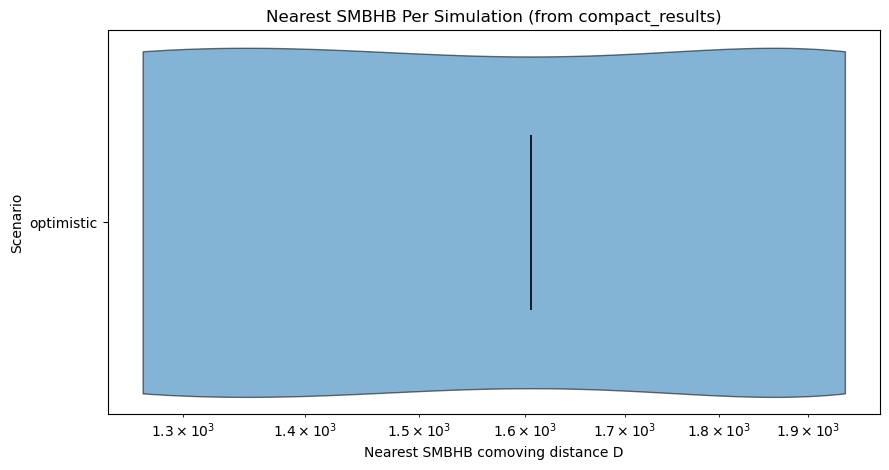

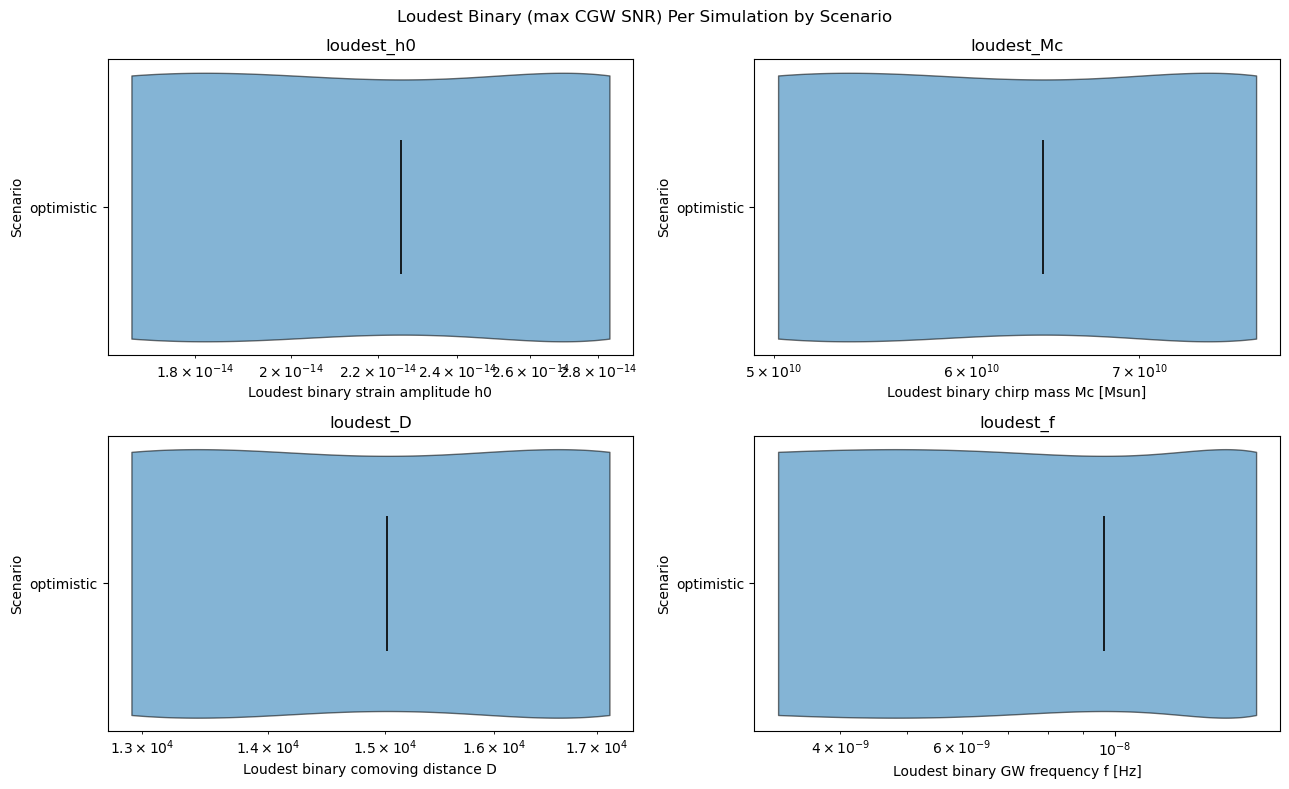

In [8]:
# Violin plots: one violin per scenario, parameter on x-axis (horizontal violins).

import matplotlib.pyplot as plt


scenario_order = [s for s in SCENARIOS if s in set(cgw_sim_df.get('scenario', []))]
scenario_colors = {
    'optimistic': '#1f77b4',
    'realistic': '#ff7f0e',
    'pessimistic': '#2ca02c',
}


def _horizontal_scenario_violin(ax, df, value_col: str, xlabel: str, logx: bool = False):
    values = [
        df.loc[(df['scenario'] == s) & np.isfinite(df[value_col]), value_col].to_numpy()
        for s in scenario_order
    ]
    positions = np.arange(1, len(scenario_order) + 1)

    parts = ax.violinplot(
        values,
        positions=positions,
        vert=False,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )

    for body, s in zip(parts['bodies'], scenario_order):
        body.set_facecolor(scenario_colors.get(s, '#888888'))
        body.set_edgecolor('black')
        body.set_alpha(0.55)

    if 'cmedians' in parts:
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.2)

    ax.set_yticks(positions)
    ax.set_yticklabels(scenario_order)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Scenario')
    if logx:
        ax.set_xscale('log')


if cgw_sim_df.empty:
    raise RuntimeError('No CGW simulation table available to plot.')


# 1) nearest SMBHB distance per simulation
fig, ax = plt.subplots(figsize=(9, 4.8))
_horizontal_scenario_violin(
    ax,
    cgw_sim_df,
    value_col='nearest_D',
    xlabel='Nearest SMBHB comoving distance D',
    logx=True,
)
ax.set_title('Nearest SMBHB Per Simulation (from compact_results)')
fig.tight_layout()


# 2) loudest-by-CGW binary parameters per simulation
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_cfg = [
    ('loudest_h0', 'Loudest binary strain amplitude h0', True),
    ('loudest_Mc', 'Loudest binary chirp mass Mc [Msun]', True),
    ('loudest_D', 'Loudest binary comoving distance D', True),
    ('loudest_f', 'Loudest binary GW frequency f [Hz]', True),
]

for ax, (col, label, use_logx) in zip(axes.ravel(), plot_cfg):
    _horizontal_scenario_violin(ax, cgw_sim_df, value_col=col, xlabel=label, logx=use_logx)
    ax.set_title(col)

fig.suptitle('Loudest Binary (max CGW SNR) Per Simulation by Scenario')
fig.tight_layout()

In [ ]:
# Sky maps for loudest-by-CGW binaries per simulation, with pulsar positions overlaid.

import numpy as np
import matplotlib.pyplot as plt


def _wrap_to_aitoff_lon(ra_rad: np.ndarray) -> np.ndarray:
    # Convert RA in [0, 2pi) to Aitoff longitude in [-pi, pi].
    return ((ra_rad + np.pi) % (2.0 * np.pi)) - np.pi

def _get_ind_psr_ra_dec_rad(p):
    """
    Get RA and Dec in radians from a libstempo tempopulsar object,
    handling both equatorial (RAJ/DECJ) and ecliptic (ELONG/ELAT) par files.
    Tempo2 always converts internally, so param[param_raj].val[0] is always
    populated — but from Python the safest route is to check which keys exist.
    """
    pars = set(p.pars(which='set'))
    
    if 'RAJ' in pars and 'DECJ' in pars:
        ra  = float(p['RAJ'].val)   # already in radians
        dec = float(p['DECJ'].val)  # already in radians
    elif 'ELONG' in pars and 'ELAT' in pars:
        # ecliptic coords — convert via astropy
        from astropy.coordinates import SkyCoord
        import astropy.units as u
        c = SkyCoord(lon=float(p['ELONG'].val) * u.rad,
                     lat=float(p['ELAT'].val)  * u.rad,
                     frame='geocentricmeanecliptic')
        icrs = c.icrs
        ra  = icrs.ra.rad
        dec = icrs.dec.rad
    else:
        raise ValueError(f"Pulsar {p.name}: cannot find RAJ/DECJ or ELONG/ELAT in {pars}")
    
    return ra, dec


def _get_pulsar_ra_dec(psrs_obj):
    ras, decs = [], []
    for p in psrs_obj:
        ra, dec = _get_ind_psr_ra_dec_rad(p)
        ras.append(ra)
        decs.append(dec)
    return np.asarray(ras), np.asarray(decs)


def _try_load_pulsars_for_overlay():
    if 'psrs_clean' in globals() and globals()['psrs_clean'] is not None:
        return globals()['psrs_clean']
    try:
        from data_loader import load_pulsars, filter_pulsars_15yr
        psrs_unfiltered = load_pulsars(verbose=False)
        psrs_clean_local, _, _ = filter_pulsars_15yr(psrs_unfiltered, verbose=False)
        return psrs_clean_local
    except Exception as e:
        print(f'Could not load pulsars for overlay: {e}')
        return None


if cgw_sim_df.empty:
    raise RuntimeError('No CGW simulation table available to plot sky maps.')


sky_df = cgw_sim_df[np.isfinite(cgw_sim_df['loudest_ra']) & np.isfinite(cgw_sim_df['loudest_dec'])].copy()
if sky_df.empty:
    raise RuntimeError('No valid RA/Dec values for loudest-by-CGW sources.')


pulsar_overlay = _try_load_pulsars_for_overlay()
pulsar_ra = np.array([])
pulsar_dec = np.array([])
if pulsar_overlay is not None:
    pulsar_ra, pulsar_dec = _get_pulsar_ra_dec(pulsar_overlay)


# Sky map 1: loudest binaries as dots (scenario-colored), with pulsars
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(111, projection='aitoff')

for scenario in scenario_order:
    sub = sky_df[sky_df['scenario'] == scenario]
    if sub.empty:
        continue
    ax.scatter(
        _wrap_to_aitoff_lon(sub['loudest_ra'].to_numpy()),
        sub['loudest_dec'].to_numpy(),
        s=28,
        alpha=0.75,
        color=scenario_colors.get(scenario, '#888888'),
        label=f'{scenario} loudest-by-CGW',
    )

if pulsar_ra.size > 0:
    ax.scatter(
        _wrap_to_aitoff_lon(pulsar_ra),
        pulsar_dec,
        s=14,
        marker='^',
        color='k',
        alpha=0.9,
        label='Pulsars',
    )

ax.grid(True, alpha=0.35)
ax.set_title('Sky Locations of Loudest-by-CGW Binaries (dots) + Pulsar Positions')
ax.legend(loc='upper right', frameon=False, fontsize=9)
fig.tight_layout()


# Sky map 2: loudest binaries colored by CGW SNR, with pulsars
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(111, projection='aitoff')
sc = ax.scatter(
    _wrap_to_aitoff_lon(sky_df['loudest_ra'].to_numpy()),
    sky_df['loudest_dec'].to_numpy(),
    c=sky_df['loudest_cgw_snr'].to_numpy(),
    cmap='viridis',
    s=36,
    alpha=0.85,
    edgecolors='none',
)

if pulsar_ra.size > 0:
    ax.scatter(
        _wrap_to_aitoff_lon(pulsar_ra),
        pulsar_dec,
        s=14,
        marker='^',
        color='white',
        edgecolors='black',
        linewidths=0.4,
        alpha=0.95,
        label='Pulsars',
    )

cbar = plt.colorbar(sc, ax=ax, pad=0.08, shrink=0.88)
cbar.set_label('Loudest binary CGW SNR')
ax.grid(True, alpha=0.35)
ax.set_title('Sky Locations of Loudest-by-CGW Binaries (colored by CGW SNR)')
if pulsar_ra.size > 0:
    ax.legend(loc='upper right', frameon=False, fontsize=9)
fig.tight_layout()